In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pandas display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Loading data from csv 
borrowers = pd.read_csv('borrower_profiles.csv')
loans = pd.read_csv('loan_applications.csv')

# Merge loans and borrower profiles on 'borrower_id'
df = pd.merge(loans, borrowers, on = 'borrower_id', how = 'inner')

df.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.00,36,13.05,542.86,55.50,Paid Off,0,0,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.00,48,14.21,153.62,40.40,Default,138,1,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.00,36,12.37,1492.59,70.50,Paid Off,0,0,24,CO,High School,Full-Time,4,40188,543,Own,2,869
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.00,48,11.18,238.58,59.80,Default,34,1,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.00,36,9.66,359.61,44.10,Current,0,0,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928


In [2]:
# Creit rating segmentation 
score_bins = [0, 579, 639, 699, 749, 850]
score_labels = ['<580 (Poor)', '580-639 (Fair)', '640-699 (Good)', '700-749 (Very Good)', '750+ (Excellent)']
df['credit_score_group'] = pd.cut(df['credit_score'], bins=score_bins, labels=score_labels)

# Debt burden segmentation
dti_max = df['dti_ratio'].max()
if dti_max <= 1.0:
    dti_bins = [0, 0.20, 0.35, 0.50, 1.0]
else:
    dti_bins = [0, 20, 35, 50, 100]

dti_labels = ['<20% (Low)', '20-35% (Moderate)', '35-50% (High)', '>50% (Critical)']
df['dti_group'] = pd.cut(df['dti_ratio'], bins=dti_bins, labels=dti_labels)

In [3]:
# Credit score risk analysis
score_analysis = df.groupby('credit_score_group', observed=False).agg(
    total_loans=('loan_id', 'count'),
    defaulted_loans=('defaulted', 'sum'),
    default_rate_pct=('defaulted', lambda x: x.mean() * 100)
).reset_index()

print("Risk Breakdown by Credit Score")
print(score_analysis)

print('-' * 30)

# DTE (Debt-To-Income) risk analysis
dti_analysis = df.groupby('dti_group', observed=False).agg(
    total_loans=('loan_id', 'count'),
    defaulted_loans=('defaulted', 'sum'),
    default_rate_pct=('defaulted', lambda x: x.mean() * 100)
).reset_index()

print("Risk Breakdown by DTI")
print(dti_analysis)

Risk Breakdown by Credit Score
    credit_score_group  total_loans  defaulted_loans  default_rate_pct
0          <580 (Poor)           74               32             43.24
1       580-639 (Fair)          117               49             41.88
2       640-699 (Good)           93               24             25.81
3  700-749 (Very Good)           86               14             16.28
4     750+ (Excellent)          231               27             11.69
------------------------------
Risk Breakdown by DTI
           dti_group  total_loans  defaulted_loans  default_rate_pct
0         <20% (Low)           48                8             16.67
1  20-35% (Moderate)          133               14             10.53
2      35-50% (High)          150               31             20.67
3    >50% (Critical)          248               85             34.27


In [4]:
# Analysis of experience of less than 2 years
df['short_employment'] = df['years_employed'] < 2
emp_analysis = df.groupby('short_employment')['defaulted'].agg(
    total_loans='count',
    default_rate_pct=lambda x: round(x.mean() * 100, 2)
)
print(emp_analysis)

                  total_loans  default_rate_pct
short_employment                               
False                     517             22.63
True                       84             34.52


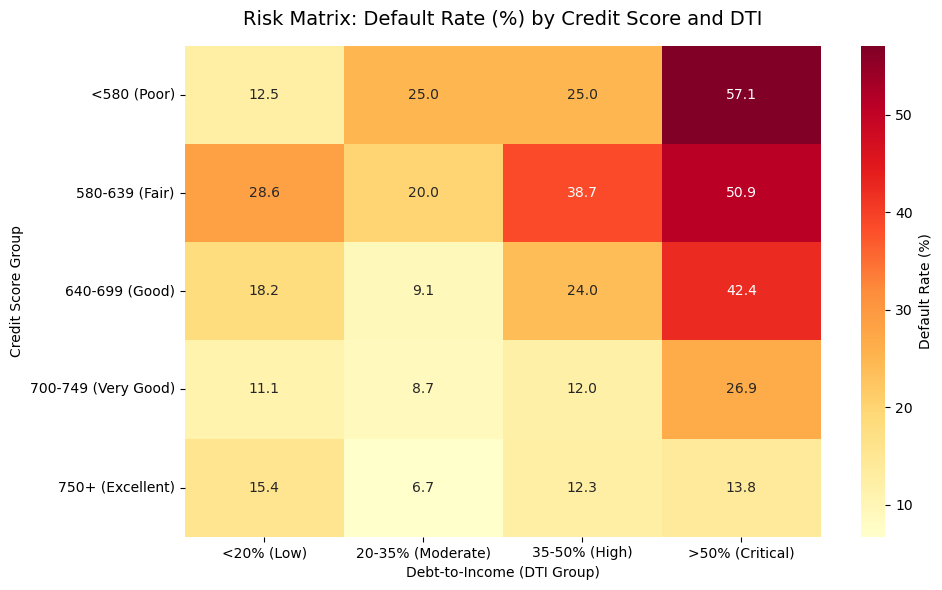

In [5]:
# Risk matrix (Defaul Rate by Credis score and DTI)
pivot_risk = df.pivot_table(
    index='credit_score_group',
    columns='dti_group',
    values='defaulted',
    aggfunc=lambda x: round(x.mean() * 100, 1),
    observed=False
)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_risk, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Default Rate (%)'})
plt.title('Risk Matrix: Default Rate (%) by Credit Score and DTI', fontsize=14, pad=15)
plt.xlabel('Debt-to-Income (DTI Group)')
plt.ylabel('Credit Score Group')
plt.tight_layout()
plt.show()

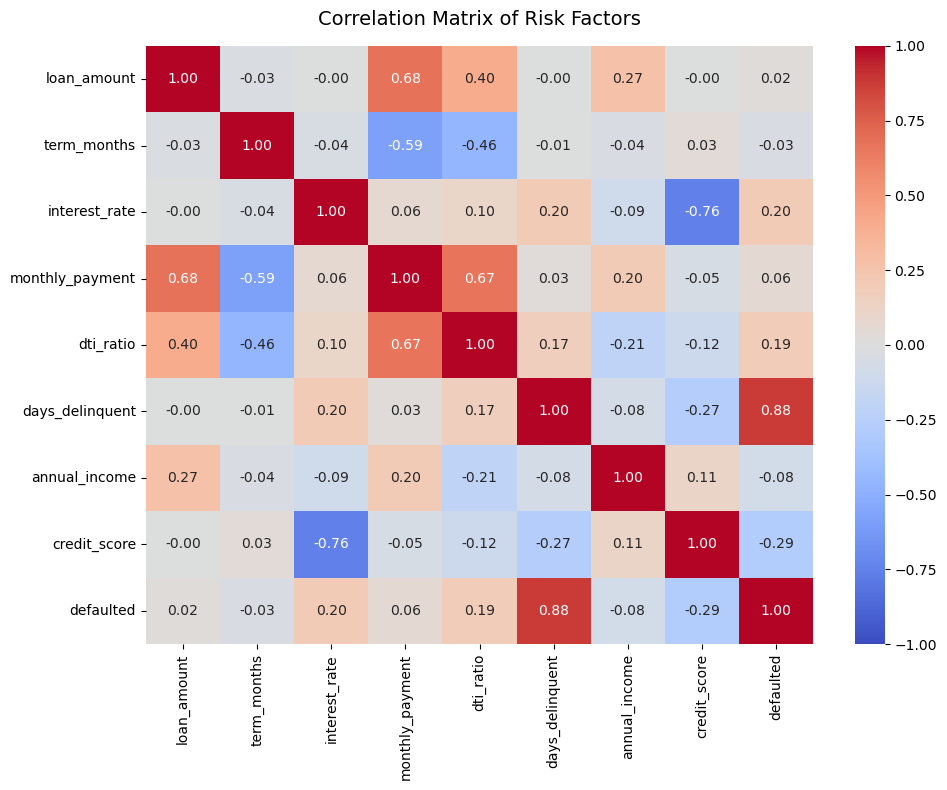

In [6]:
# Correlation matrix of risk factors
# Select numeric features for correlation analysis
numeric_cols = [
    'loan_amount', 'term_months', 'interest_rate', 'monthly_payment', 
    'dti_ratio', 'days_delinquent', 'annual_income', 'credit_score', 'defaulted'
]

corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Risk Factors', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# <font color="#2c3e50"> EDA Summary </font>

---

### <font color="#2980b9"> Key Findings</font>

1. **Credit Score as the Primary Risk Driver:**
   * Strong inverse correlation ($r = -0.29$) with loan defaults. The default rate drops sharply from <span style="color: #e74c3c; font-weight: bold; font-size: 16px;">43.2%</span> for Poor credit scores (&lt;580) down to <span style="color: #27ae60; font-weight: bold; font-size: 16px;">11.7%</span> for Excellent scores (750+).

2. **DTI Ratio Overrides Credit Quality:**
   * Debt-to-Income ratio above <mark><b>DTI &gt; 50%</b></mark> is a critical risk threshold (overall <span style="color: #c0392b; font-weight: bold; font-size: 16px;">34.3%</span> default rate).
   * High DTI severely dilutes good credit history: borrowers in the *"Good"* credit score tier (640–699) with Critical DTI (&gt;50%) still hit a high default rate of <span style="color: #e74c3c; font-weight: bold;">42.4%</span>.

> ### <span style="color: #c0392b;"> High-Risk Hotspot (Underwriting Trap)</span>
> The interaction matrix highlights the most dangerous segment: **Credit Score &lt;580 + DTI &gt;50%**, yielding a staggering <span style="color: #900C3F; font-size: 20px; font-weight: bold;">57.1%</span> default rate.

4. **The Rate Burden Loop:**
   * High negative correlation ($r = -0.76$) between `credit_score` and `interest_rate`. Penalizing low-score borrowers with high interest rates inflates their `monthly_payment`, driving up DTI and inadvertently escalating default risk.
